In [ ]:
# 3 - modeling

# The purpose of this noetbook is to use autogluon to see if density can be predicted from
# the percent of chain extender (evaluate using R^2 and MAE)


In [1]:
# import the data
from pathlib import Path
import pandas as pd

project_root = Path.cwd().resolve().parent if 'notebooks' in str(Path.cwd()) else Path.cwd().resolve()
excel_path = project_root / 'data' / 'raw' / 'Compiled Data.xlsx'

df = pd.read_excel(excel_path)

subset_columns = ['TEM', 'Joncryl', 'NC513', 'PEG-DE', 'NGDE', 'Avg_Density_g_cm3']
df = df[subset_columns].copy()

print(df.head())

# print the number of rows
print("Number of rows in the dataset:", len(df))


   TEM  Joncryl  NC513  PEG-DE  NGDE  Avg_Density_g_cm3
0  8.0      NaN    NaN     NaN   NaN           0.192000
1  NaN      0.7    NaN     NaN   NaN           0.195000
2  NaN      1.0    NaN     NaN   NaN           0.159000
3  NaN      1.5    NaN     NaN   NaN           0.159933
4  NaN      2.0    NaN     NaN   NaN           0.201000
Number of rows in the dataset: 25


In [5]:
# create a model using autogluon to predict density from the percent of chain extender
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from autogluon.tabular import TabularPredictor

feature_cols = ['TEM', 'Joncryl', 'NC513', 'PEG-DE', 'NGDE']
target_col = 'Avg_Density_g_cm3'

# Keep the distribution of chain extender types roughly balanced across train/test splits.
# Each row is dominated by one chain extender, so stratifying on the max column works well.
df = df.copy()
df['chain_extender_group'] = df[feature_cols].idxmax(axis=1)

train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.2,
    random_state=42,
    stratify=df['chain_extender_group'],
)

train_df = df.loc[train_idx, feature_cols + [target_col]].copy()
test_df = df.loc[test_idx, feature_cols + [target_col]].copy()

predictor = TabularPredictor(
    label=target_col,
    problem_type='regression',
    eval_metric='r2',
)

predictor.fit(
    train_data=train_df,
    time_limit=None,
    presets='best_quality',
    num_bag_folds=8,
    num_stack_levels=1,
)

# Evaluate on the 20% holdout set that was not used for training.
print(predictor.evaluate(test_df))

predictions = predictor.predict(test_df.drop(columns=[target_col]))
mae = mean_absolute_error(test_df[target_col], predictions)
r2 = r2_score(test_df[target_col], predictions)

print(f'MAE: {mae:.6f}')
print(f'R^2: {r2:.6f}')

leaderboard = predictor.leaderboard(test_df)
print(leaderboard.head())


c:\Users\Brooke Brocker\foam-project\.venv\Lib\site-packages\sklearn\utils\_param_validation.py:14: UserWarning: A NumPy version >=1.23.5 and <2.5.0 is required for this version of SciPy (detected version 2.5.3)
  from scipy.sparse import csr_array, issparse
No path specified. Models will be saved in: "AutogluonModels\ag-20260912_230818"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.6.1
Python Version:     3.13.5
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          22
Pytorch Version:    2.13.0+cpu
CUDA Version:       CUDA is not available
Memory Avail:       0.76 GB / 15.61 GB (4.9%)
Disk Space Avail:   743.97 GB / 951.65 GB (78.2%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configurati

[1000]	valid_set's l2: 0.00097205	valid_set's r2: 0.761031
[2000]	valid_set's l2: 0.000959289	valid_set's r2: 0.764168
[3000]	valid_set's l2: 0.000956728	valid_set's r2: 0.764798
[4000]	valid_set's l2: 0.000954845	valid_set's r2: 0.765261
[5000]	valid_set's l2: 0.000953828	valid_set's r2: 0.765511
[6000]	valid_set's l2: 0.0009533	valid_set's r2: 0.765641
[7000]	valid_set's l2: 0.000953059	valid_set's r2: 0.7657
[8000]	valid_set's l2: 0.000952918	valid_set's r2: 0.765735
[9000]	valid_set's l2: 0.000952877	valid_set's r2: 0.765745
[10000]	valid_set's l2: 0.000952854	valid_set's r2: 0.765751
[1000]	valid_set's l2: 0.000668444	valid_set's r2: 0.892397
[2000]	valid_set's l2: 0.000639736	valid_set's r2: 0.897018
[3000]	valid_set's l2: 0.0006396	valid_set's r2: 0.89704
[4000]	valid_set's l2: 0.000637237	valid_set's r2: 0.897421
[5000]	valid_set's l2: 0.000636888	valid_set's r2: 0.897477
[6000]	valid_set's l2: 0.000636768	valid_set's r2: 0.897496
[7000]	valid_set's l2: 0.000636743	valid_set's 

	0.8441	 = Validation score   (r2)
	39.94s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: CatBoost_r177_BAG_L1 ...
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=16, gpus=0)
	0.8787	 = Validation score   (r2)
	10.12s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: NeuralNetTorch_r79_BAG_L1 ...
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=16, gpus=0)
	0.8879	 = Validation score   (r2)
	2.83s	 = Training   runtime
	0.07s	 = Validation runtime
Fitting model: LightGBM_r131_BAG_L1 ...
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=16, gpus=0)
	-0.1303	 = Validation score   (r2)
	4.22s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: NeuralNetFastAI_r191_BAG_L1 ...
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential

[1000]	valid_set's l2: 0.000367778	valid_set's r2: -0.451079
[1000]	valid_set's l2: 0.00535315	valid_set's r2: -0.316018
[1000]	valid_set's l2: 0.00670836	valid_set's r2: -0.0798796


	0.1717	 = Validation score   (r2)
	6.53s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: NeuralNetFastAI_r145_BAG_L1 ...
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=16, gpus=0)
		NDFrame.fillna() got an unexpected keyword argument 'downcast'
Detailed Traceback:
Traceback (most recent call last):
  File "c:\Users\Brooke Brocker\foam-project\.venv\Lib\site-packages\autogluon\tabular\trainer\abstract_trainer.py", line 2438, in _train_and_save
    model = self._train_single(**model_fit_kwargs)
  File "c:\Users\Brooke Brocker\foam-project\.venv\Lib\site-packages\autogluon\tabular\trainer\abstract_trainer.py", line 2301, in _train_single
    model = model.fit(
        X=X,
    ...<6 lines>...
        **model_fit_kwargs,
    )
  File "c:\Users\Brooke Brocker\foam-project\.venv\Lib\site-packages\autogluon\core\models\abstract\abstract_model.py", line 1399, in fit
    out = self._fit(**kwargs)
  File "c:\Users\Broo

...

[1000]	valid_set's l2: 0.000367778	valid_set's r2: -0.451079
[1000]	valid_set's l2: 0.00535321	valid_set's r2: -0.316032
[2000]	valid_set's l2: 0.00535315	valid_set's r2: -0.316018
[1000]	valid_set's l2: 0.00670839	valid_set's r2: -0.0798855
[2000]	valid_set's l2: 0.00670836	valid_set's r2: -0.0798796


	0.1736	 = Validation score   (r2)
	9.92s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: NeuralNetTorch_r158_BAG_L1 ...
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=16, gpus=0)
	0.8311	 = Validation score   (r2)
	2.45s	 = Training   runtime
	0.07s	 = Validation runtime
Fitting model: CatBoost_r86_BAG_L1 ...
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=16, gpus=0)
	0.8588	 = Validation score   (r2)
	3.27s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: NeuralNetFastAI_r37_BAG_L1 ...
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=16, gpus=0)
		NDFrame.fillna() got an unexpected keyword argument 'downcast'
Detailed Traceback:
Traceback (most recent call last):
  File "c:\Users\Brooke Brocker\foam-project\.venv\Lib\site-packages\autogluon\tabular\trainer\abstract_trainer.py",

[1000]	valid_set's l2: 0.00138452	valid_set's r2: 0.808504
[2000]	valid_set's l2: 0.00130982	valid_set's r2: 0.818837
[3000]	valid_set's l2: 0.0012957	valid_set's r2: 0.820789
[4000]	valid_set's l2: 0.00128937	valid_set's r2: 0.821665
[5000]	valid_set's l2: 0.00128845	valid_set's r2: 0.821792
[6000]	valid_set's l2: 0.00128822	valid_set's r2: 0.821823
[7000]	valid_set's l2: 0.00128817	valid_set's r2: 0.82183
[8000]	valid_set's l2: 0.00128816	valid_set's r2: 0.821832
[9000]	valid_set's l2: 0.00128816	valid_set's r2: 0.821833
[10000]	valid_set's l2: 0.00128816	valid_set's r2: 0.821833
[1000]	valid_set's l2: 0.000140297	valid_set's r2: 0.839518
[2000]	valid_set's l2: 0.000135082	valid_set's r2: 0.845483
[3000]	valid_set's l2: 0.000134929	valid_set's r2: 0.845659
[4000]	valid_set's l2: 0.000134924	valid_set's r2: 0.845665
[5000]	valid_set's l2: 0.000134924	valid_set's r2: 0.845665
[6000]	valid_set's l2: 0.000134924	valid_set's r2: 0.845665
[7000]	valid_set's l2: 0.000134924	valid_set's r2: 

	0.9005	 = Validation score   (r2)
	40.56s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: CatBoost_r177_BAG_L2 ...
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=16, gpus=0)
	0.9387	 = Validation score   (r2)
	4028.89s	 = Training   runtime
	0.02s	 = Validation runtime
Fitting model: NeuralNetTorch_r79_BAG_L2 ...
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=16, gpus=0)
	0.8869	 = Validation score   (r2)
	2.47s	 = Training   runtime
	0.09s	 = Validation runtime
Fitting model: LightGBM_r131_BAG_L2 ...
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=16, gpus=0)
	-0.0706	 = Validation score   (r2)
	3.65s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: NeuralNetFastAI_r191_BAG_L2 ...
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequenti

KeyboardInterrupt: 

In [2]:
# Choose the best model based on validation performance from the leaderboard, then evaluate that single model on the holdout test set
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from autogluon.tabular import TabularPredictor

feature_cols = ['TEM', 'Joncryl', 'NC513', 'PEG-DE', 'NGDE']
target_col = 'Avg_Density_g_cm3'

df = df.copy()
df['chain_extender_group'] = df[feature_cols].idxmax(axis=1)
train_idx, test_idx = train_test_split(             #finds the indicies for the train and test sets
    df.index,
    test_size=0.2,
    random_state=42,
    stratify=df['chain_extender_group'],
)

test_df = df.loc[test_idx, feature_cols + [target_col]].copy()
saved_path = project_root / 'notebooks' / 'AutogluonModels' / 'ag-20260912_230818' / 'ds_sub_fit' / 'sub_fit_ho'  # location of object the has the info for all the models
predictor = TabularPredictor.load(str(saved_path))      # loads all of the model runs and their info
leaderboard = predictor.leaderboard(test_df)
best_row = leaderboard.sort_values('score_val', ascending=False).iloc[0]
best_model_name = best_row['model']

print('Best validation model on leaderboard:', best_model_name)

# Evaluate only the best validation model on the holdout test set using AutoGluon's supported API.
predictions = predictor.predict(test_df[feature_cols], model=best_model_name)
mae = mean_absolute_error(test_df[target_col], predictions)
r2 = r2_score(test_df[target_col], predictions)

print(f'MAE for best validation model: {mae:.6f}')
print(f'R^2 for best validation model: {r2:.6f}')


Best validation model on leaderboard: RandomForestMSE_BAG_L2
MAE for best validation model: 0.013865
R^2 for best validation model: 0.655012


Test examples used for evaluation:
 TEM  Joncryl  NC513  PEG-DE  NGDE  Avg_Density_g_cm3  predicted_density  abs_error
 NaN      NaN    NaN     NaN   3.0           0.248000           0.210889   0.037111
 NaN      1.0    3.0     2.0   NaN           0.161600           0.156440   0.005160
 NaN      NaN    3.0     1.0   NaN           0.155567           0.160448   0.004881
 NaN      2.0    NaN     NaN   NaN           0.201000           0.200495   0.000505
 NaN      NaN    NaN     1.0   NaN           0.197907           0.176238   0.021669
Figure saved to: C:\Users\Brooke Brocker\foam-project\reports\figures\test_set_actual_vs_predicted_density.png


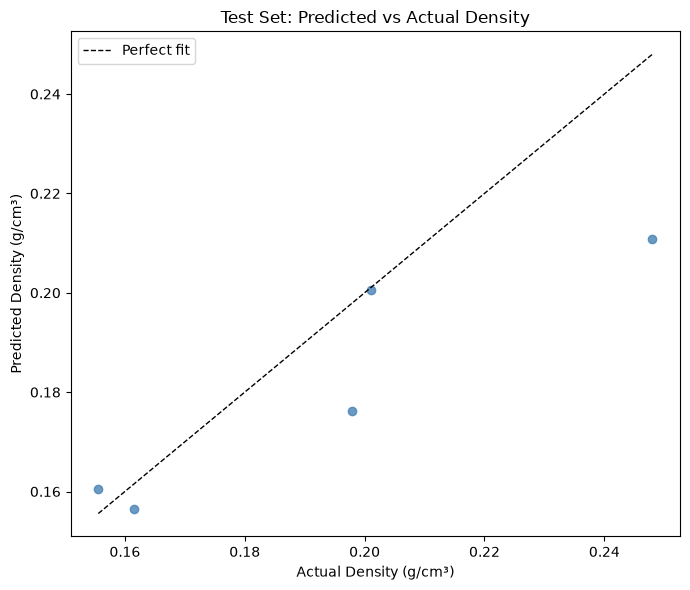

In [3]:
# Plot test-set predictions vs actual density values for the best leaderboard model
from pathlib import Path
import matplotlib.pyplot as plt

# Use the same split and best model selected above
actual = test_df[target_col].to_numpy()
predicted = predictor.predict(test_df[feature_cols], model=best_model_name).to_numpy()

# Print the test examples with actual and predicted density values
comparison_df = test_df[[*feature_cols, target_col]].copy()
comparison_df['predicted_density'] = predicted
comparison_df['abs_error'] = (comparison_df[target_col] - comparison_df['predicted_density']).abs()
print('Test examples used for evaluation:')
print(comparison_df.round(6).to_string(index=False))

plt.figure(figsize=(7, 6))
plt.scatter(actual, predicted, color='steelblue', alpha=0.8)

min_val = min(actual.min(), predicted.min())
max_val = max(actual.max(), predicted.max())
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', linewidth=1, label='Perfect fit')

plt.xlabel('Actual Density (g/cm³)')
plt.ylabel('Predicted Density (g/cm³)')
plt.title('Test Set: Predicted vs Actual Density')
plt.legend()
plt.tight_layout()

output_dir = project_root / 'reports' / 'figures'
output_dir.mkdir(parents=True, exist_ok=True)
fig_path = output_dir / 'test_set_actual_vs_predicted_density.png'
plt.savefig(fig_path, dpi=300)
print(f'Figure saved to: {fig_path}')
plt.show()
